# Apartment Price Prediction Pipeline

This notebook performs data loading, preprocessing, exploratory data analysis (EDA), and predictive modeling to estimate apartment rental prices in the United States.

The workflow includes:
- Loading the dataset
- Storing and retrieving the data from a SQLite database
- Cleaning and preprocessing the data
- Creating visualizations to explore pricing patterns
- Building and evaluating predictive models

## 1. Import Libraries

In [1]:
# Import required libraries for data handling, visualization, database work, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Data Loading and Database Setup

In [2]:
# Load the apartment rental dataset from the CSV file
df = pd.read_csv(
    "apartments_for_rent_classified_10K.csv",
    encoding="latin1",
    sep=";",
    on_bad_lines="skip"
)

# Display dataset dimensions
df.shape

(10000, 22)

In [3]:
# Create a SQLite database connection
conn = sqlite3.connect("apartments.db")

# Store the dataset in a database table
df.to_sql("apartments", conn, if_exists="replace", index=False)

# Retrieve the dataset back from the database into Jupyter
df_db = pd.read_sql("SELECT * FROM apartments", conn)

# Display the first few rows to confirm the database load worked
df_db.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",None,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,None,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",None,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",None,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,None,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",None,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",None,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,None,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [4]:
## 3. Initial Data Inspection

In [5]:
# View column names
df.columns

Index(['id', 'category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time'],
      dtype='object')

In [6]:
# Review data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   8252 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-null   object 
 18  latitud

In [7]:
# Review data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   8252 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-null   object 
 18  latitud

In [8]:
# Check missing values in each column
df.isnull().sum()

id                  0
category            0
title               0
body                0
amenities        3549
bathrooms          34
bedrooms            7
currency            0
fee                 0
has_photo           0
pets_allowed     1748
price               0
price_display       0
price_type          0
square_feet         0
address          3327
cityname           77
state              77
latitude           10
longitude          10
source              0
time                0
dtype: int64

## 4. Data Preprocessing

In [9]:
# Create a copy of the dataset so the original remains unchanged
df_clean = df.copy()

In [10]:
# Check for duplicate rows
df_clean.duplicated().sum()

0

In [11]:
# Review missing values in the main features used for analysis
df_clean[['price', 'square_feet', 'bedrooms', 'bathrooms', 'cityname', 'state', 'latitude', 'longitude']].isnull().sum()

price           0
square_feet     0
bedrooms        7
bathrooms      34
cityname       77
state          77
latitude       10
longitude      10
dtype: int64

In [12]:
# Drop rows missing key location information
df_clean = df_clean.dropna(subset=['cityname', 'state', 'latitude', 'longitude'])

In [13]:
# Fill missing bedroom and bathroom values using the median
df_clean['bedrooms'] = df_clean['bedrooms'].fillna(df_clean['bedrooms'].median())
df_clean['bathrooms'] = df_clean['bathrooms'].fillna(df_clean['bathrooms'].median())

In [14]:
# Review summary statistics for price
df_clean['price'].describe()

count     9923.000000
mean      1486.135644
std       1078.112000
min        200.000000
25%        949.000000
50%       1270.000000
75%       1695.000000
max      52500.000000
Name: price, dtype: float64

In [15]:
# Remove invalid price values
df_clean = df_clean[df_clean['price'] > 0]

In [16]:
# Review summary statistics for square footage
df_clean['square_feet'].describe()

count     9923.000000
mean       946.152474
std        657.216433
min        101.000000
25%        649.000000
50%        803.000000
75%       1100.000000
max      40000.000000
Name: square_feet, dtype: float64

In [17]:
# Remove invalid square footage values
df_clean = df_clean[df_clean['square_feet'] > 0]

In [18]:
# Review summary statistics for bedrooms and bathrooms
df_clean[['bedrooms', 'bathrooms']].describe()

,bedrooms,bathrooms
count,9923.000000,9923.000000
mean,1.744231,1.379472
std,0.942451,0.615581
min,0.000000,1.000000
25%,1.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,9.000000,8.500000


In [19]:
# Remove any invalid bedroom or bathroom values
df_clean = df_clean[df_clean['bedrooms'] >= 0]
df_clean = df_clean[df_clean['bathrooms'] >= 0]

In [20]:
# Display the shape of the cleaned dataset
df_clean.shape

(9923, 22)

In [21]:
# Save the cleaned dataset for later use
df_clean.to_csv("apartments_cleaned.csv", index=False)

## 5. Exploratory Data Analysis (EDA)

To improve readability of the visualizations, a trimmed plotting dataset is created to reduce the impact of extreme outliers.

In [22]:
# Create a filtered dataset for plotting to reduce the impact of extreme outliers
df_plot = df_clean[
    (df_clean['price'] < 5000) &
    (df_clean['square_feet'] < 3000)
]

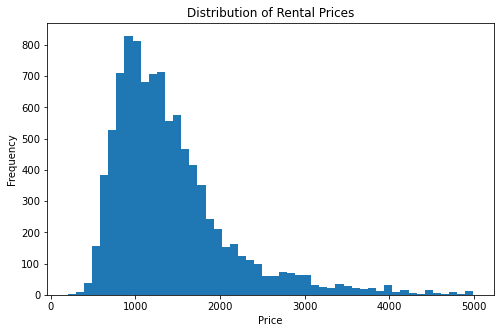

In [23]:
# Plot the distribution of rental prices
plt.figure(figsize=(8, 5))
plt.hist(df_plot['price'], bins=50)
plt.title("Distribution of Rental Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

**Insight:** Rental prices are right-skewed, with most listings concentrated in a lower-to-mid price range and fewer high-priced apartments creating outliers.

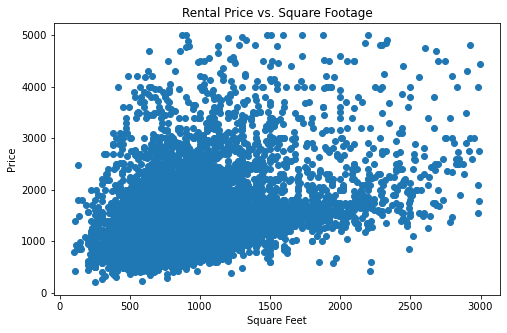

In [24]:
# Plot rental price versus square footage
plt.figure(figsize=(8, 5))
plt.scatter(df_plot['square_feet'], df_plot['price'])
plt.title("Rental Price vs. Square Footage")
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.show()

**Insight:** There is a positive relationship between apartment size and rental price, although the relationship is not perfectly linear because other variables such as location also affect pricing.

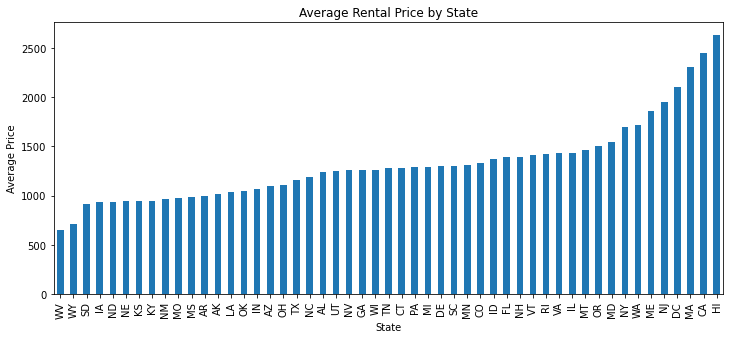

In [25]:
# Calculate and plot average rental price by state
avg_price_state = df_plot.groupby('state')['price'].mean().sort_values()

plt.figure(figsize=(12, 5))
avg_price_state.plot(kind='bar')
plt.title("Average Rental Price by State")
plt.xlabel("State")
plt.ylabel("Average Price")
plt.show()

**Insight:** Average rental prices vary noticeably by state, showing that location is a major factor in determining apartment prices.

In [26]:
# Generate summary statistics for the main numerical features
df_clean[['price', 'square_feet', 'bedrooms', 'bathrooms']].describe()

,price,square_feet,bedrooms,bathrooms
count,9923.000000,9923.000000,9923.000000,9923.000000
mean,1486.135644,946.152474,1.744231,1.379472
std,1078.112000,657.216433,0.942451,0.615581
min,200.000000,101.000000,0.000000,1.000000
25%,949.000000,649.000000,1.000000,1.000000
50%,1270.000000,803.000000,2.000000,1.000000
75%,1695.000000,1100.000000,2.000000,2.000000
max,52500.000000,40000.000000,9.000000,8.500000


## 6. Baseline Model: Linear Regression

A baseline Linear Regression model is built using only structural apartment features:
- square footage
- bedrooms
- bathrooms

In [27]:
# Select baseline features and target variable
features = ['square_feet', 'bedrooms', 'bathrooms']
target = 'price'

df_model = df_clean[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the baseline Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Baseline Linear Regression")
print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

Baseline Linear Regression
MAE: 518.5375552253357
RMSE: 1034.1607123100014
R^2: -0.33793388325435214


In [28]:
# Display baseline model coefficients
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,square_feet,0.896246
1,bedrooms,-150.551341
2,bathrooms,274.403119


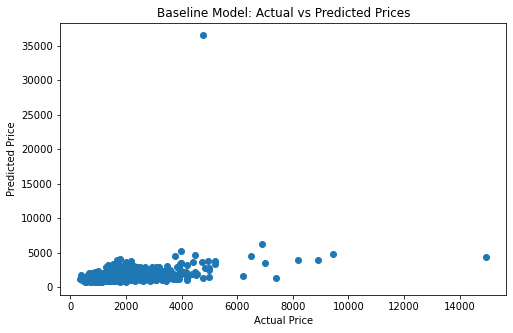

In [29]:
# Plot actual versus predicted prices for the baseline model
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Baseline Model: Actual vs Predicted Prices")
plt.show()

**Interpretation:** The baseline model provides a simple starting point, but its performance is limited because it does not account for location, which appears to be an important factor in rental price prediction.

## 7. Improved Models with Location Features

To improve performance, state is added as a location-based feature using one-hot encoding.  
Both Linear Regression and Random Forest are tested and compared.

In [30]:
# Prepare a second modeling dataset using the filtered data and add state as a feature
df_model2 = df_plot[['price', 'square_feet', 'bedrooms', 'bathrooms', 'state']].dropna()

# Convert the categorical state column into numeric dummy variables
df_model2 = pd.get_dummies(df_model2, columns=['state'], drop_first=True)

# Separate features and target
X2 = df_model2.drop('price', axis=1)
y2 = df_model2['price']

# Split the data into training and testing sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [31]:
# Train the improved Linear Regression model
lr2 = LinearRegression()
lr2.fit(X_train2, y_train2)

# Generate predictions and evaluate performance
y_pred_lr2 = lr2.predict(X_test2)

print("Improved Linear Regression")
print("MAE:", mean_absolute_error(y_test2, y_pred_lr2))
print("RMSE:", np.sqrt(mean_squared_error(y_test2, y_pred_lr2)))
print("R^2:", r2_score(y_test2, y_pred_lr2))

Improved Linear Regression
MAE: 309.08307516362356
RMSE: 450.8752133770576
R^2: 0.5920149398505201


In [32]:
# Train the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train2, y_train2)

# Generate predictions and evaluate performance
y_pred_rf = rf.predict(X_test2)

print("Random Forest")
print("MAE:", mean_absolute_error(y_test2, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test2, y_pred_rf)))
print("R^2:", r2_score(y_test2, y_pred_rf))

Random Forest
MAE: 304.8853935728316
RMSE: 462.8595596859659
R^2: 0.5700380596199752


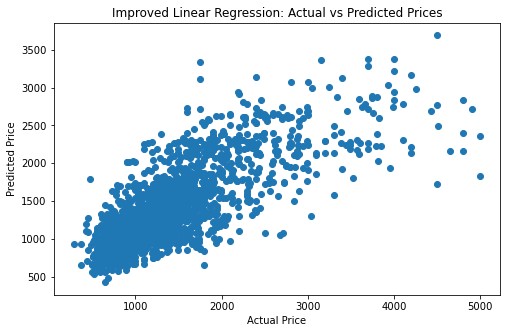

In [33]:
# Plot actual versus predicted prices for the improved Linear Regression model
plt.figure(figsize=(8, 5))
plt.scatter(y_test2, y_pred_lr2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Improved Linear Regression: Actual vs Predicted Prices")
plt.show()

## 8. Results and Interpretation

The baseline Linear Regression model performed poorly, showing that structural apartment features alone were not sufficient for predicting rental prices accurately.

After adding location information through the state feature, model performance improved substantially. The improved Linear Regression model achieved the strongest overall performance, while Random Forest produced similar results.

These findings suggest that location is one of the most important factors in apartment rental pricing and that relatively simple models can perform well when meaningful features are included.

## 9. Conclusion

This notebook demonstrated a full apartment price prediction pipeline, including:
- data loading
- database storage and retrieval
- preprocessing
- exploratory analysis
- predictive modeling
- model evaluation

The results show that both apartment characteristics and location are important for explaining rental prices, with location providing a major improvement in predictive performance.